# Distributed Transient Analysis Validation

This notebook validates the distributed transient IR-drop analysis using the `netlist_sampled` test case
with the **distributed DDM solver** (`DistributedDDMSolver`).

**Key differences from the flat transient notebook:**
- Uses pre-parsed tile pkl files instead of `NetlistParser`
- Single `DistributedDDMSolver` handles DC, quasi-static, and transient modes
- Current source data lives on tile workers (preprocessed via `preprocess_sources()`)
- Peak tracking is lazy -- stays on workers until `.as_flat()` is called
- Requires `model.shutdown()` at the end

**Validation points:**
1. Distributed DC solve produces a reference IR-drop
2. Quasi-static and transient (BE/Trap) analyses run correctly
3. Capacitive smoothing effects are visible in transient vs quasi-static comparison
4. Time-domain waveforms and peak tracking work end-to-end

## 1. Setup and Imports

In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import interpolate

warnings.filterwarnings('ignore')

# Change to project root so TileConfig relative paths resolve correctly
os.chdir(Path(__file__).parent.parent if '__file__' in dir() else Path('..'))

from distributed.model import create_distributed_model, load_distributed_partitions
from distributed.solver import DistributedDDMSolver

import logging
logging.basicConfig(level=logging.DEBUG,
                    format='%(asctime)s %(name)s %(levelname)s: %(message)s',
                    datefmt='%H:%M:%S')

from solver.coupled_system import set_partial_factor_threshold
set_partial_factor_threshold(1)

%matplotlib inline
print(f"Working directory: {os.getcwd()}")
print("Imports successful!")


14:43:15 matplotlib.pyplot DEBUG: Loaded backend module://matplotlib_inline.backend_inline version unknown.
14:43:15 matplotlib.pyplot DEBUG: Loaded backend module://matplotlib_inline.backend_inline version unknown.


Working directory: /wv/bwdev1/patrasej/dev/sigma_dvd/prototype
Imports successful!


## 2. Load Distributed Model

In [2]:
pkl_dir = Path('netlist/netlist_sampled/distributed_pkl')

print(f"Loading distributed partitions from {pkl_dir}...")
bundle = load_distributed_partitions(str(pkl_dir))

model = create_distributed_model(bundle, backend='ray')

print(f"\nModel created successfully!")
print(f"  Vdd: {model.vdd} V")
print(f"  Net: {model.net_name}")
print(f"  Tiles: {len(model.metadata.tile_configs)}")
print(f"  Pad nodes: {model.pad_nodes}")

print(f"\nPer-tile sizes:")
for tid, n_int in sorted(model.tile_interior_counts.items()):
    n_bnd = len(model.tile_boundary_nodes[tid])
    print(f"  Tile {tid}: {n_int} interior, {n_bnd} boundary")

14:43:15 distributed.model INFO: Loaded metadata from netlist/netlist_sampled/distributed_pkl: 9 tiles, 1973 shared boundary nodes


Loading distributed partitions from netlist/netlist_sampled/distributed_pkl...


2026-03-19 14:43:17,403	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-19 14:43:25,291	INFO worker.py:2013 -- Started a local Ray instance.
14:43:28 distributed.model INFO: Interface: 1996 nodes (1973 boundary + 27 die attachment)
14:43:35 distributed.model INFO: Model created in 19.881s: 9 tiles, 133584 interior nodes, 3957 boundary entries, 1996 interface nodes



Model created successfully!
  Vdd: 0.66 V
  Net: VDD_XLV
  Tiles: 9
  Pad nodes: {'VDD_XLV_vsrc'}

Per-tile sizes:
  Tile (0, 0): 15189 interior, 471 boundary
  Tile (0, 1): 15049 interior, 508 boundary
  Tile (0, 2): 15118 interior, 481 boundary
  Tile (1, 0): 15171 interior, 622 boundary
  Tile (1, 1): 15026 interior, 658 boundary
  Tile (1, 2): 15098 interior, 630 boundary
  Tile (2, 0): 13453 interior, 178 boundary
  Tile (2, 1): 13864 interior, 217 boundary
  Tile (2, 2): 15616 interior, 192 boundary


## 3. Static DC IR-Drop (Reference)

In [3]:
solver = DistributedDDMSolver(model)

t0 = time.perf_counter()
ctx = solver.prepare(verbose=True)
dc_result = solver.solve_dc(ctx, verbose=True)
dc_time = time.perf_counter() - t0

ir_drop = dc_result.ir_drop
max_drop_node = max(ir_drop, key=ir_drop.get)
max_drop = ir_drop[max_drop_node]

print(f"\nDC Analysis Results (time: {dc_time*1000:.1f} ms):")
print(f"  Max IR-drop: {max_drop*1000:.4f} mV")
print(f"  Max IR-drop node: {max_drop_node}")
print(f"  Min voltage: {model.vdd - max_drop:.6f} V")
print(f"  Mean IR-drop: {np.mean(list(ir_drop.values()))*1000:.4f} mV")

14:43:40 distributed.result_factorization DEBUG: Tile (0, 0) factor_and_compute_schur:
  G_ii: 15,189 x 15,189, nnz=61,511 (density 0.02666%), 862.9 KB
  G_pp: 471 x 471, nnz=473
  G_pi: 471 x 15,189, nnz=605  |  G_ip: 15,189 x 471, nnz=605
  Block system memory: 862.9 KB
  factor_interior: 4.994s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 5.024s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:43:40 distributed.result_factorization DEBUG: Tile (0, 1) factor_and_compute_schur:
  G_ii: 15,049 x 15,049, nnz=60,751 (density 0.02682%), 857.2 KB
  G_pp: 508 x 508, nnz=510
  G_pi: 508 x 15,049, nnz=755  |  G_ip: 15,049 x 508, nnz=755
  Block system memory: 857.2 KB
  factor_interior: 5.101s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 5.126s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:43:40 distributed.result_factorization DEBUG: Tile (0, 2) factor_and_compute_schur:
  G


DC Analysis Results (time: 8841.9 ms):
  Max IR-drop: 1.6353 mV
  Max IR-drop node: 1673000_1958400_M0
  Min voltage: 0.658365 V
  Mean IR-drop: 0.5094 mV


## 4. Preprocess Current Sources

Load and optionally smooth time-varying current sources on tile workers.

In [4]:
# Simulation parameters
t_start = 0.0
t_end = 10e-9     # 10 ns
dt = 10e-12        # 10 ps timestep
n_points = 1001    # for quasi-static

print(f"Preprocessing sources (dt={dt*1e12:.0f} ps, t_end={t_end*1e9:.0f} ns)...")
t0 = time.perf_counter()
smoothed = solver.preprocess_sources(
    time_step=dt,
    t_start=t_start,
    t_end=t_end,
    smooth=True,
    verbose=True,
)
preprocess_time = time.perf_counter() - t0

print(f"\nPreprocessing time: {preprocess_time*1000:.1f} ms")
print(f"Smoothed: {smoothed.smoothed}")
print(f"\nPer-tile source stats:")
total_sources = 0
for tid, stats in sorted(smoothed.per_tile_stats.items()):
    n = stats.get('n_sources', 0)
    total_sources += n
    print(f"  Tile {tid}: {n} sources, "
          f"{stats.get('n_pulses', 0)} pulses, "
          f"{stats.get('n_pwls', 0)} PWLs")
print(f"  Total: {total_sources} sources")

Preprocessing sources (dt=10 ps, t_end=10 ns)...


14:43:47 distributed.solver_td INFO: VCS init: 59149 total sources across 9 tiles (9 from cache)
14:43:47 distributed.solver_td INFO:   init_vcs: 0.1046s
14:43:47 distributed.solver_td INFO:   smooth_sources: 3.1443s



Preprocessing time: 3252.2 ms
Smoothed: True

Per-tile source stats:
  Tile (0, 0): 7538 sources, 11836 pulses, 0 PWLs
  Tile (0, 1): 7834 sources, 16056 pulses, 0 PWLs
  Tile (0, 2): 7000 sources, 5281 pulses, 0 PWLs
  Tile (1, 0): 6375 sources, 6754 pulses, 0 PWLs
  Tile (1, 1): 7525 sources, 8797 pulses, 0 PWLs
  Tile (1, 2): 7094 sources, 9659 pulses, 0 PWLs
  Tile (2, 0): 3898 sources, 5014 pulses, 0 PWLs
  Tile (2, 1): 5059 sources, 1486 pulses, 0 PWLs
  Tile (2, 2): 6826 sources, 7732 pulses, 0 PWLs
  Total: 59149 sources


## 5. Select Tracking Nodes

Pick the worst IR-drop nodes from the DC solve to track full waveforms.

In [5]:
# Select top-5 worst nodes from DC result for waveform tracking
sorted_by_drop = sorted(ir_drop.items(), key=lambda x: x[1], reverse=True)
track_nodes = [n for n, _ in sorted_by_drop[:5]]

print("Tracking waveforms for top-5 worst DC nodes:")
for n, d in sorted_by_drop[:5]:
    print(f"  {n}: {d*1000:.4f} mV")

Tracking waveforms for top-5 worst DC nodes:
  1673000_1958400_M0: 1.6353 mV
  1638800_1958400_M0: 1.5934 mV
  989000_1588800_M0: 1.5670 mV
  1663000_1958400_M0: 1.5573 mV
  1653190_1958400_M0: 1.4679 mV


## 6. Quasi-Static Analysis

Batch DC solves at discrete time points (no capacitance effects).

In [6]:
print(f"Running quasi-static analysis ({n_points} time points)...")
t0 = time.perf_counter()
qs_ctx = solver.prepare(verbose=False)
qs_result = solver.solve_quasi_static(
    qs_ctx,
    t_start=t_start,
    t_end=t_end,
    n_points=n_points,
    smoothed_sources=smoothed,
    track_nodes=track_nodes,
    verbose=True,
)
qs_time = time.perf_counter() - t0

print(f"\nQuasi-Static Results (time: {qs_time:.1f} s):")
print(f"  Peak IR-drop: {qs_result.peak_ir_drop*1000:.4f} mV")
print(f"  Peak time: {qs_result.peak_ir_drop_time*1e9:.2f} ns")
print(f"  Time points: {len(qs_result.t_array)}")

Running quasi-static analysis (1001 time points)...


14:43:48 distributed.result_factorization DEBUG: Tile (0, 0) factor_and_compute_schur:
  G_ii: 15,189 x 15,189, nnz=61,511 (density 0.02666%), 862.9 KB
  G_pp: 471 x 471, nnz=473
  G_pi: 471 x 15,189, nnz=605  |  G_ip: 15,189 x 471, nnz=605
  Block system memory: 862.9 KB
  factor_interior: 1.031s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 1.045s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:43:48 distributed.result_factorization DEBUG: Tile (0, 1) factor_and_compute_schur:
  G_ii: 15,049 x 15,049, nnz=60,751 (density 0.02682%), 857.2 KB
  G_pp: 508 x 508, nnz=510
  G_pi: 508 x 15,049, nnz=755  |  G_ip: 15,049 x 508, nnz=755
  Block system memory: 857.2 KB
  factor_interior: 0.119s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 0.139s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:43:48 distributed.result_factorization DEBUG: Tile (0, 2) factor_and_compute_schur:
  G


Quasi-Static Results (time: 66.0 s):
  Peak IR-drop: 62.5698 mV
  Peak time: 2.28 ns
  Time points: 1001


## 7. Transient Analysis (Backward Euler)

RC transient analysis with implicit Backward Euler time integration.

In [7]:
print(f"Running transient analysis (BE, dt={dt*1e12:.0f} ps)...")
t0 = time.perf_counter()
be_dc_ctx = solver.prepare(verbose=False)
be_trans_ctx = solver.prepare_transient(dt=dt, method='be', verbose=False)
be_result = solver.solve_transient(
    be_trans_ctx,
    dc_context=be_dc_ctx,
    t_start=t_start,
    t_end=t_end,
    smoothed_sources=smoothed,
    track_nodes=track_nodes,
    verbose=True,
)
be_time = time.perf_counter() - t0

print(f"\nTransient (BE) Results (time: {be_time:.1f} s):")
print(f"  Peak IR-drop: {be_result.peak_ir_drop*1000:.4f} mV")
print(f"  Peak time: {be_result.peak_ir_drop_time*1e9:.2f} ns")
print(f"  Has capacitance: {be_result.has_capacitance}")
print(f"  Integration method: {be_result.integration_method}")

Running transient analysis (BE, dt=10 ps)...


14:44:55 distributed.result_factorization DEBUG: Tile (0, 0) factor_and_compute_schur:
  G_ii: 15,189 x 15,189, nnz=61,511 (density 0.02666%), 862.9 KB
  G_pp: 471 x 471, nnz=473
  G_pi: 471 x 15,189, nnz=605  |  G_ip: 15,189 x 471, nnz=605
  Block system memory: 862.9 KB
  factor_interior: 1.261s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 1.373s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:44:55 distributed.result_factorization DEBUG: Tile (0, 1) factor_and_compute_schur:
  G_ii: 15,049 x 15,049, nnz=60,751 (density 0.02682%), 857.2 KB
  G_pp: 508 x 508, nnz=510
  G_pi: 508 x 15,049, nnz=755  |  G_ip: 15,049 x 508, nnz=755
  Block system memory: 857.2 KB
  factor_interior: 0.638s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 0.704s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:44:55 distributed.result_factorization DEBUG: Tile (0, 2) factor_and_compute_schur:
  G


Transient (BE) Results (time: 70.9 s):
  Peak IR-drop: 50.9123 mV
  Peak time: 4.78 ns
  Has capacitance: True
  Integration method: be


## 8. Transient Analysis (Trapezoidal)

RC transient analysis with second-order Trapezoidal integration.

In [8]:
print(f"Running transient analysis (Trap, dt={dt*1e12:.0f} ps)...")
t0 = time.perf_counter()
trap_dc_ctx = solver.prepare(verbose=False)
trap_trans_ctx = solver.prepare_transient(dt=dt, method='trap', verbose=False)
trap_result = solver.solve_transient(
    trap_trans_ctx,
    dc_context=trap_dc_ctx,
    t_start=t_start,
    t_end=t_end,
    smoothed_sources=smoothed,
    track_nodes=track_nodes,
    verbose=True,
)
trap_time = time.perf_counter() - t0

print(f"\nTransient (Trap) Results (time: {trap_time:.1f} s):")
print(f"  Peak IR-drop: {trap_result.peak_ir_drop*1000:.4f} mV")
print(f"  Peak time: {trap_result.peak_ir_drop_time*1e9:.2f} ns")
print(f"  Has capacitance: {trap_result.has_capacitance}")
print(f"  Integration method: {trap_result.integration_method}")

Running transient analysis (Trap, dt=10 ps)...


14:46:09 distributed.result_factorization DEBUG: Tile (0, 0) factor_and_compute_schur:
  G_ii: 15,189 x 15,189, nnz=61,511 (density 0.02666%), 862.9 KB
  G_pp: 471 x 471, nnz=473
  G_pi: 471 x 15,189, nnz=605  |  G_ip: 15,189 x 471, nnz=605
  Block system memory: 862.9 KB
  factor_interior: 4.819s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 4.846s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:46:09 distributed.result_factorization DEBUG: Tile (0, 1) factor_and_compute_schur:
  G_ii: 15,049 x 15,049, nnz=60,751 (density 0.02682%), 857.2 KB
  G_pp: 508 x 508, nnz=510
  G_pi: 508 x 15,049, nnz=755  |  G_ip: 15,049 x 508, nnz=755
  Block system memory: 857.2 KB
  factor_interior: 4.799s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 4.820s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:46:09 distributed.result_factorization DEBUG: Tile (0, 2) factor_and_compute_schur:
  G


Transient (Trap) Results (time: 74.4 s):
  Peak IR-drop: 78.5102 mV
  Peak time: 2.28 ns
  Has capacitance: True
  Integration method: trap


## 9. Validation: Compare Methods

In [9]:
print("=== Method Comparison ===")
print(f"\n{'Method':<20} {'Peak IR-drop (mV)':>18} {'Peak Time (ns)':>15}")
print("-" * 55)
print(f"{'Quasi-Static':<20} {qs_result.peak_ir_drop*1000:>18.4f} {qs_result.peak_ir_drop_time*1e9:>15.2f}")
print(f"{'Transient (BE)':<20} {be_result.peak_ir_drop*1000:>18.4f} {be_result.peak_ir_drop_time*1e9:>15.2f}")
print(f"{'Transient (Trap)':<20} {trap_result.peak_ir_drop*1000:>18.4f} {trap_result.peak_ir_drop_time*1e9:>15.2f}")

# Compute differences
diff_be = abs(be_result.peak_ir_drop - qs_result.peak_ir_drop)
diff_trap = abs(trap_result.peak_ir_drop - qs_result.peak_ir_drop)
diff_be_trap = abs(be_result.peak_ir_drop - trap_result.peak_ir_drop)

print(f"\nPeak Differences:")
print(f"  QS vs BE:     {diff_be*1e6:.2f} uV")
print(f"  QS vs Trap:   {diff_trap*1e6:.2f} uV")
print(f"  BE vs Trap:   {diff_be_trap*1e6:.2f} uV")

print(f"\nNote: With capacitance, Backward Euler is more damped (lower peaks),")
print(f"while Trapezoidal is second-order accurate. Without capacitance,")
print(f"all methods should match quasi-static exactly.")

=== Method Comparison ===

Method                Peak IR-drop (mV)  Peak Time (ns)
-------------------------------------------------------
Quasi-Static                    62.5698            2.28
Transient (BE)                  50.9123            4.78
Transient (Trap)                78.5102            2.28

Peak Differences:
  QS vs BE:     11657.45 uV
  QS vs Trap:   15940.46 uV
  BE vs Trap:   27597.91 uV

Note: With capacitance, Backward Euler is more damped (lower peaks),
while Trapezoidal is second-order accurate. Without capacitance,
all methods should match quasi-static exactly.


## 10. Visualization: Time Series Comparison

14:47:18 matplotlib.font_manager DEBUG: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
14:47:18 matplotlib.font_manager DEBUG: findfont: score(FontEntry(fname='/home/patrasej/workspace_dev2/local/miniconda3/envs/pyspice/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
14:47:18 matplotlib.font_manager DEBUG: findfont: score(FontEntry(fname='/home/patrasej/workspace_dev2/local/miniconda3/envs/pyspice/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
14:47:18 matplotlib.font_manager DEBUG: findfont: score(FontEntry(fname='/home/patrasej/workspace_dev2/local/miniconda3/envs/pyspice/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/De

14:47:18 matplotlib.font_manager DEBUG: findfont: score(FontEntry(fname='/usr/share/fonts/google-noto-cjk/NotoSerifCJK-Black.ttc', name='Noto Serif CJK JP', style='normal', variant='normal', weight=900, stretch='normal', size='scalable')) = 10.525
14:47:18 matplotlib.font_manager DEBUG: findfont: score(FontEntry(fname='/usr/share/fonts/julietaula-montserrat/Montserrat-Medium.otf', name='Montserrat', style='normal', variant='normal', weight=500, stretch='normal', size='scalable')) = 10.145
14:47:18 matplotlib.font_manager DEBUG: findfont: score(FontEntry(fname='/usr/share/fonts/julietaula-montserrat/MontserratAlternates-LightItalic.otf', name='Montserrat Alternates', style='italic', variant='normal', weight=300, stretch='normal', size='scalable')) = 11.145
14:47:18 matplotlib.font_manager DEBUG: findfont: score(FontEntry(fname='/usr/share/fonts/liberation-serif/LiberationSerif-BoldItalic.ttf', name='Liberation Serif', style='italic', variant='normal', weight=700, stretch='normal', size=

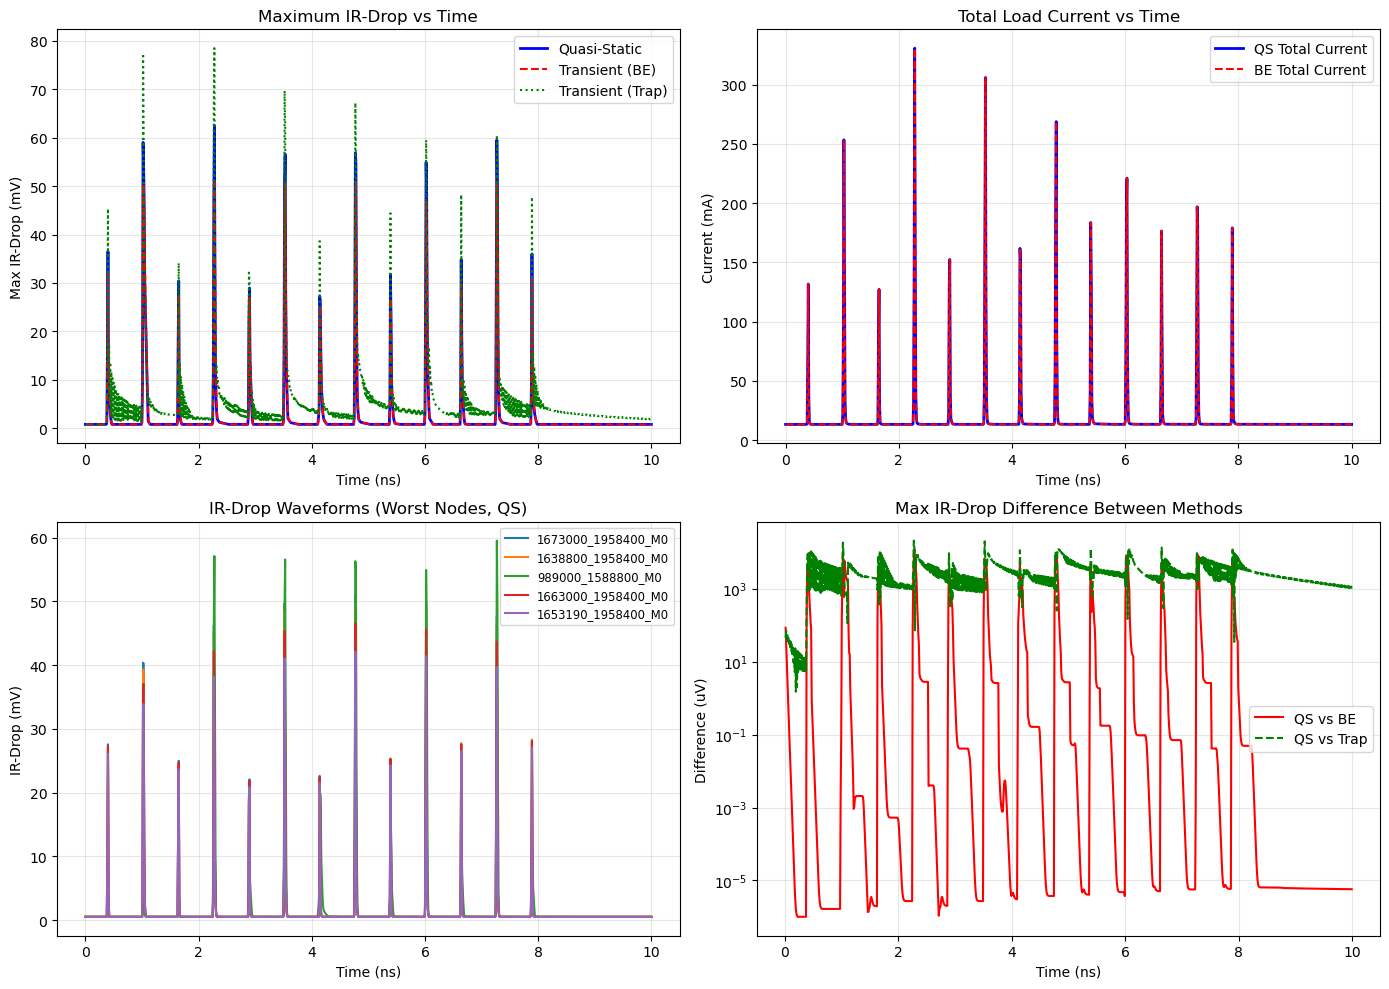

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Max IR-drop vs time
ax = axes[0, 0]
ax.plot(qs_result.t_array * 1e9, qs_result.max_ir_drop_per_time * 1000,
        'b-', linewidth=2, label='Quasi-Static')
ax.plot(be_result.t_array * 1e9, be_result.max_ir_drop_per_time * 1000,
        'r--', linewidth=1.5, label='Transient (BE)')
ax.plot(trap_result.t_array * 1e9, trap_result.max_ir_drop_per_time * 1000,
        'g:', linewidth=1.5, label='Transient (Trap)')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Max IR-Drop (mV)')
ax.set_title('Maximum IR-Drop vs Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Top-right: Total current vs time
ax = axes[0, 1]
ax.plot(qs_result.t_array * 1e9, qs_result.total_current_per_time,
        'b-', linewidth=2, label='QS Total Current')
ax.plot(be_result.t_array * 1e9, be_result.total_current_per_time,
        'r--', linewidth=1.5, label='BE Total Current')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Current (mA)')
ax.set_title('Total Load Current vs Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom-left: Tracked node waveforms (quasi-static)
ax = axes[1, 0]
for node in track_nodes[:5]:
    if node in qs_result.tracked_ir_drop:
        waveform = qs_result.tracked_ir_drop[node]
        label = f'{str(node)[:20]}...' if len(str(node)) > 20 else str(node)
        ax.plot(qs_result.t_array * 1e9, waveform * 1000,
                linewidth=1.5, label=label)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('IR-Drop (mV)')
ax.set_title('IR-Drop Waveforms (Worst Nodes, QS)')
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3)

# Bottom-right: Method difference over time
ax = axes[1, 1]
# Interpolate transient results to QS time grid for comparison
be_interp = interpolate.interp1d(be_result.t_array,
                                  be_result.max_ir_drop_per_time,
                                  fill_value='extrapolate')
trap_interp = interpolate.interp1d(trap_result.t_array,
                                    trap_result.max_ir_drop_per_time,
                                    fill_value='extrapolate')

# Use the overlapping time range
t_common = qs_result.t_array[
    (qs_result.t_array >= be_result.t_array[0]) &
    (qs_result.t_array <= be_result.t_array[-1])
]
if len(t_common) > 0:
    qs_at_common = interpolate.interp1d(
        qs_result.t_array, qs_result.max_ir_drop_per_time,
        fill_value='extrapolate'
    )(t_common)
    diff_be_arr = np.abs(qs_at_common - be_interp(t_common)) * 1e6  # uV
    diff_trap_arr = np.abs(qs_at_common - trap_interp(t_common)) * 1e6

    ax.semilogy(t_common * 1e9, diff_be_arr + 1e-6,
                'r-', linewidth=1.5, label='QS vs BE')
    ax.semilogy(t_common * 1e9, diff_trap_arr + 1e-6,
                'g--', linewidth=1.5, label='QS vs Trap')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Difference (uV)')
ax.set_title('Max IR-Drop Difference Between Methods')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Visualization: Per-Node Waveform Comparison

Compare QS vs BE vs Trap waveforms for the worst node.

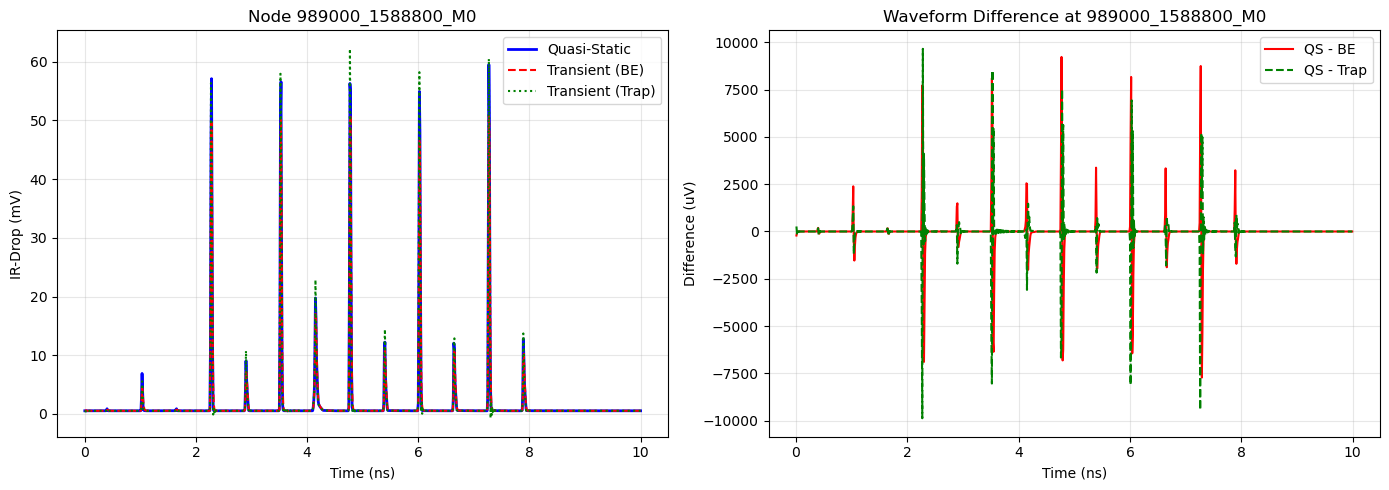

Node: 989000_1588800_M0
  Max diff QS vs BE:   9232.80 uV
  Max diff QS vs Trap: 9878.36 uV
  RMS diff QS vs BE:   1037.15 uV
  RMS diff QS vs Trap: 964.17 uV


In [11]:
# Find a node tracked in all three results
common_tracked = (
    set(qs_result.tracked_ir_drop.keys()) &
    set(be_result.tracked_ir_drop.keys()) &
    set(trap_result.tracked_ir_drop.keys())
)

if common_tracked:
    test_node = max(common_tracked,
                    key=lambda n: np.max(qs_result.tracked_ir_drop[n]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Overlaid waveforms
    ax = axes[0]
    ax.plot(qs_result.t_array * 1e9,
            qs_result.tracked_ir_drop[test_node] * 1000,
            'b-', linewidth=2, label='Quasi-Static')
    ax.plot(be_result.t_array * 1e9,
            be_result.tracked_ir_drop[test_node] * 1000,
            'r--', linewidth=1.5, label='Transient (BE)')
    ax.plot(trap_result.t_array * 1e9,
            trap_result.tracked_ir_drop[test_node] * 1000,
            'g:', linewidth=1.5, label='Transient (Trap)')
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('IR-Drop (mV)')
    ax.set_title(f'Node {test_node}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Right: Difference from QS
    ax = axes[1]
    be_node_interp = interpolate.interp1d(
        be_result.t_array, be_result.tracked_ir_drop[test_node],
        fill_value='extrapolate'
    )
    trap_node_interp = interpolate.interp1d(
        trap_result.t_array, trap_result.tracked_ir_drop[test_node],
        fill_value='extrapolate'
    )

    if len(t_common) > 0:
        qs_node_at_common = interpolate.interp1d(
            qs_result.t_array, qs_result.tracked_ir_drop[test_node],
            fill_value='extrapolate'
        )(t_common)
        ax.plot(t_common * 1e9,
                (qs_node_at_common - be_node_interp(t_common)) * 1e6,
                'r-', linewidth=1.5, label='QS - BE')
        ax.plot(t_common * 1e9,
                (qs_node_at_common - trap_node_interp(t_common)) * 1e6,
                'g--', linewidth=1.5, label='QS - Trap')
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Difference (uV)')
    ax.set_title(f'Waveform Difference at {test_node}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Quantitative comparison
    if len(t_common) > 0:
        diff_be_node = np.abs(qs_node_at_common - be_node_interp(t_common))
        diff_trap_node = np.abs(qs_node_at_common - trap_node_interp(t_common))
        print(f"Node: {test_node}")
        print(f"  Max diff QS vs BE:   {np.max(diff_be_node)*1e6:.2f} uV")
        print(f"  Max diff QS vs Trap: {np.max(diff_trap_node)*1e6:.2f} uV")
        print(f"  RMS diff QS vs BE:   {np.sqrt(np.mean(diff_be_node**2))*1e6:.2f} uV")
        print(f"  RMS diff QS vs Trap: {np.sqrt(np.mean(diff_trap_node**2))*1e6:.2f} uV")
else:
    print("No common tracked nodes found across all three results.")

## 12. Peak IR-Drop Distribution

Collect per-node peak data from workers and compare distributions.

Collection time: 944.7 ms
Nodes with peaks: QS=135572, BE=135572, Trap=135572


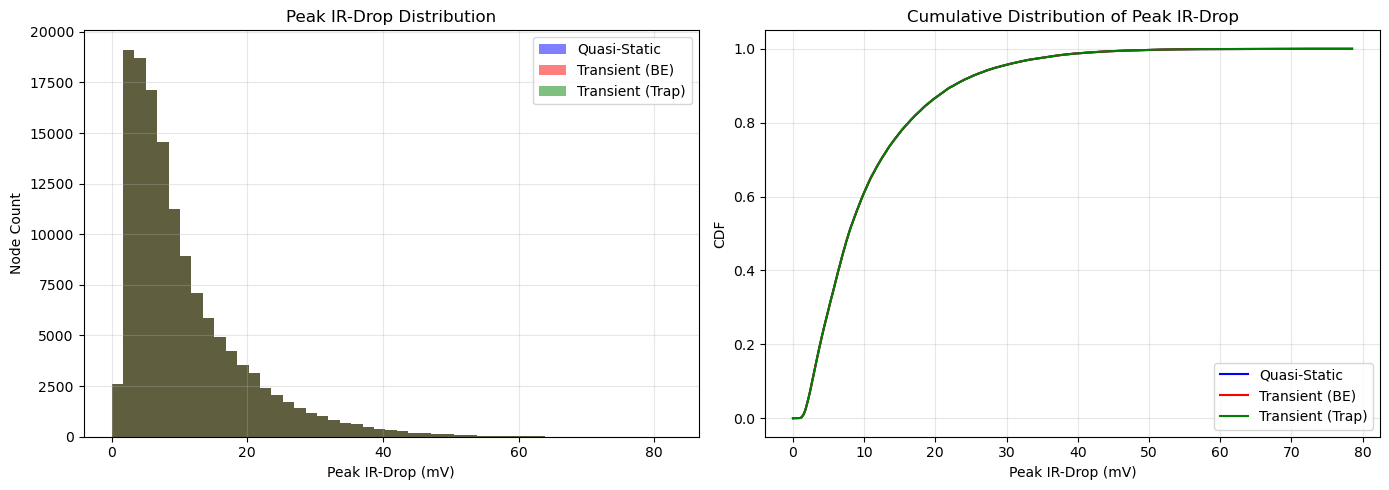


Statistic               QS (mV)    BE (mV)  Trap (mV)
----------------------------------------------------
Max:::::::::::::::::    78.5102    78.5102    78.5102
Mean::::::::::::::::    10.6401    10.6401    10.6401
P99:::::::::::::::::    41.5367    41.5367    41.5367
P95:::::::::::::::::    28.6718    28.6718    28.6718


In [12]:
# Collect peak data from workers (lazy -- first call triggers collection)
print("Collecting peak data from workers...")
t0 = time.perf_counter()
qs_peaks = qs_result.as_flat()
be_peaks = be_result.as_flat()
trap_peaks = trap_result.as_flat()
collect_time = time.perf_counter() - t0
print(f"Collection time: {collect_time*1000:.1f} ms")
print(f"Nodes with peaks: QS={len(qs_peaks)}, BE={len(be_peaks)}, Trap={len(trap_peaks)}")

# Extract peak drop values
qs_drops = np.array([d for d, _ in qs_peaks.values()]) * 1000  # mV
be_drops = np.array([d for d, _ in be_peaks.values()]) * 1000
trap_drops = np.array([d for d, _ in trap_peaks.values()]) * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of peak IR-drops
ax = axes[0]
bins = np.linspace(0, max(qs_drops.max(), be_drops.max(), trap_drops.max()) * 1.05, 50)
ax.hist(qs_drops, bins=bins, alpha=0.5, label='Quasi-Static', color='blue')
ax.hist(be_drops, bins=bins, alpha=0.5, label='Transient (BE)', color='red')
ax.hist(trap_drops, bins=bins, alpha=0.5, label='Transient (Trap)', color='green')
ax.set_xlabel('Peak IR-Drop (mV)')
ax.set_ylabel('Node Count')
ax.set_title('Peak IR-Drop Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: CDF comparison
ax = axes[1]
for drops, label, color in [
    (qs_drops, 'Quasi-Static', 'blue'),
    (be_drops, 'Transient (BE)', 'red'),
    (trap_drops, 'Transient (Trap)', 'green'),
]:
    sorted_drops = np.sort(drops)
    cdf = np.arange(1, len(sorted_drops) + 1) / len(sorted_drops)
    ax.plot(sorted_drops, cdf, linewidth=1.5, label=label, color=color)
ax.set_xlabel('Peak IR-Drop (mV)')
ax.set_ylabel('CDF')
ax.set_title('Cumulative Distribution of Peak IR-Drop')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n{'Statistic':<20} {'QS (mV)':>10} {'BE (mV)':>10} {'Trap (mV)':>10}")
print("-" * 52)
print(f"{'Max'::<20} {qs_drops.max():>10.4f} {be_drops.max():>10.4f} {trap_drops.max():>10.4f}")
print(f"{'Mean'::<20} {qs_drops.mean():>10.4f} {be_drops.mean():>10.4f} {trap_drops.mean():>10.4f}")
print(f"{'P99'::<20} {np.percentile(qs_drops, 99):>10.4f} {np.percentile(be_drops, 99):>10.4f} {np.percentile(trap_drops, 99):>10.4f}")
print(f"{'P95'::<20} {np.percentile(qs_drops, 95):>10.4f} {np.percentile(be_drops, 95):>10.4f} {np.percentile(trap_drops, 95):>10.4f}")

## 13. Performance Summary

In [13]:
print("=== Performance Summary ===")
print(f"\nTiles: {len(model.metadata.tile_configs)}")
print(f"Backend: {type(model.backend).__name__}")

print(f"\n{'Phase':<25} {'Wall Time':>12}")
print("-" * 39)
print(f"{'Preprocess sources':<25} {preprocess_time*1000:>10.1f} ms")
print(f"{'DC solve':<25} {dc_time*1000:>10.1f} ms")
print(f"{'Quasi-static':<25} {qs_time:>10.1f} s")
print(f"{'Transient (BE)':<25} {be_time:>10.1f} s")
print(f"{'Transient (Trap)':<25} {trap_time:>10.1f} s")

n_qs_steps = len(qs_result.t_array)
n_be_steps = len(be_result.t_array)
n_trap_steps = len(trap_result.t_array)

print(f"\n{'Method':<25} {'Steps':>8} {'ms/step':>10}")
print("-" * 45)
print(f"{'Quasi-static':<25} {n_qs_steps:>8} {qs_time/n_qs_steps*1000:>10.2f}")
print(f"{'Transient (BE)':<25} {n_be_steps:>8} {be_time/n_be_steps*1000:>10.2f}")
print(f"{'Transient (Trap)':<25} {n_trap_steps:>8} {trap_time/n_trap_steps*1000:>10.2f}")

# Detailed timing breakdown from solve_metadata (only numeric entries)
print(f"\n--- QS Timing Breakdown ---")
for k, v in sorted(qs_result.solve_metadata.get('timings', {}).items()):
    if isinstance(v, (int, float)):
        print(f"  {k:<30} {v:>8.3f} s")

print(f"\n--- BE Timing Breakdown ---")
for k, v in sorted(be_result.solve_metadata.get('timings', {}).items()):
    if isinstance(v, (int, float)):
        print(f"  {k:<30} {v:>8.3f} s")

=== Performance Summary ===

Tiles: 9
Backend: RayBackend

Phase                        Wall Time
---------------------------------------
Preprocess sources            3252.2 ms
DC solve                      8841.9 ms
Quasi-static                    66.0 s
Transient (BE)                  70.9 s
Transient (Trap)                74.4 s

Method                       Steps    ms/step
---------------------------------------------
Quasi-static                  1001      65.88
Transient (BE)                1000      70.88
Transient (Trap)              1000      74.43

--- QS Timing Breakdown ---
  collect_waveforms                 0.007 s
  init_peak_tracking                0.057 s
  time_loop                        61.168 s
  total                            61.233 s

--- BE Timing Breakdown ---
  collect_waveforms                 0.007 s
  dc_initial                        0.144 s
  init_peak_tracking                0.009 s
  time_loop                        59.595 s
  total                 

## 14. Final Verification: Context Lifecycle API

Validate the new active context lifecycle: explicit `prepare()` / `release()`, `save()` / `load()`,
and both transient IC paths (`dc_context` vs `ic_voltages`).

### 14a. DC → release → transient flow (LUs never coexist)

Demonstrates the memory-optimized flow where the DC LU is freed before the transient LU is created.

In [14]:
# --- DC → release → transient (LUs never coexist) ---
print("=== DC → release → transient flow ===\n")

# 1. DC phase
dc_ctx_lifecycle = solver.prepare()
dc_result_lifecycle = solver.solve_dc(dc_ctx_lifecycle)
ic_voltages = dc_result_lifecycle  # Pass DistributedSolveResult directly (per-tile, no flattening)
print(f"DC solve: max IR-drop = {max(dc_result_lifecycle.ir_drop.values())*1000:.4f} mV")
print(f"DC context factored: {dc_ctx_lifecycle.is_factored}")

# 2. Release DC before transient
dc_ctx_lifecycle.release()
print(f"DC context released: is_factored={dc_ctx_lifecycle.is_factored}")
print(f"DC topology preserved: {dc_ctx_lifecycle.topology is not None}")

# 3. Transient phase (using ic_voltages, skipping DC solve)
trans_ctx_lifecycle = solver.prepare_transient(dt=dt, method='be')
lifecycle_result = solver.solve_transient(
    trans_ctx_lifecycle,
    ic_voltages=ic_voltages,
    t_start=t_start,
    t_end=t_end,
    smoothed_sources=smoothed,
    verbose=False,
)
print(f"\nTransient (ic_voltages): peak IR-drop = {lifecycle_result.peak_ir_drop*1000:.4f} mV")

# 4. Compare against the BE result from cell 14 (which used dc_context path)
diff = abs(lifecycle_result.peak_ir_drop - be_result.peak_ir_drop)
print(f"Diff vs dc_context path: {diff*1e6:.2f} uV")
assert diff < 1e-6, f"IC paths should produce identical results, got diff={diff}"
print("✓ Both IC paths produce identical results!")

trans_ctx_lifecycle.release()

=== DC → release → transient flow ===



14:47:32 distributed.result_factorization DEBUG: Tile (0, 0) factor_and_compute_schur:
  G_ii: 15,189 x 15,189, nnz=61,511 (density 0.02666%), 862.9 KB
  G_pp: 471 x 471, nnz=473
  G_pi: 471 x 15,189, nnz=605  |  G_ip: 15,189 x 471, nnz=605
  Block system memory: 862.9 KB
  factor_interior: 1.710s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 1.723s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:47:32 distributed.result_factorization DEBUG: Tile (0, 1) factor_and_compute_schur:
  G_ii: 15,049 x 15,049, nnz=60,751 (density 0.02682%), 857.2 KB
  G_pp: 508 x 508, nnz=510
  G_pi: 508 x 15,049, nnz=755  |  G_ip: 15,049 x 508, nnz=755
  Block system memory: 857.2 KB
  factor_interior: 1.806s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 1.821s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:47:32 distributed.result_factorization DEBUG: Tile (0, 2) factor_and_compute_schur:
  G

DC solve: max IR-drop = 1.6353 mV
DC context factored: True
DC context released: is_factored=False
DC topology preserved: True


14:47:38 distributed.result_factorization DEBUG: Tile (0, 0) factor_transient_system:
  A_ii: nnz=61,511  |  A_pp: nnz=473
  C_ii cap nodes: 15189 / 15189  |  C_pp cap nodes: 3 / 471
  Total tile cap: 18981.3 fF  |  C_coeff: 0.1000
  factor_interior: 2.267s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 2.279s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:47:38 distributed.result_factorization DEBUG: Tile (0, 1) factor_transient_system:
  A_ii: nnz=60,751  |  A_pp: nnz=510
  C_ii cap nodes: 15049 / 15049  |  C_pp cap nodes: 32 / 508
  Total tile cap: 19076.5 fF  |  C_coeff: 0.1000
  factor_interior: 2.084s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 2.102s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:47:38 distributed.result_factorization DEBUG: Tile (0, 2) factor_transient_system:
  A_ii: nnz=60,942  |  A_pp: nnz=481
  C_ii cap nodes: 15118 / 15118  |  C_pp cap nod


Transient (ic_voltages): peak IR-drop = 50.9123 mV
Diff vs dc_context path: 0.00 uV
✓ Both IC paths produce identical results!


### 14b. Save/Load Round-Trip

Demonstrates saving a DC context to disk, loading it back, re-factoring the coordinator LU,
and verifying the solve produces identical results.

In [15]:
import tempfile
from distributed.result import DistributedSolverContext

print("=== Save/Load Round-Trip ===\n")

# 1. Prepare and solve DC (reference)
ctx_save = solver.prepare()
dc_result_ref = solver.solve_dc(ctx_save)
ref_voltages = dc_result_ref.flatten()
ref_max_drop = max(dc_result_ref.ir_drop.values())
print(f"Reference DC max IR-drop: {ref_max_drop*1000:.4f} mV")

# 2. Save to disk
with tempfile.TemporaryDirectory() as tmpdir:
    save_path = os.path.join(tmpdir, 'dc_context.pkl')
    ctx_save.save(save_path)
    print(f"Saved to: {save_path}")
    print(f"  File size: {os.path.getsize(save_path) / 1024:.1f} KB")

    # 3. Release the original context
    ctx_save.release()
    print(f"Original context released: is_factored={ctx_save.is_factored}")

    # 4. Load from disk
    ctx_loaded = DistributedSolverContext.load(model, save_path)
    print(f"Loaded context: is_factored={ctx_loaded.is_factored}")
    print(f"  Topology preserved: {ctx_loaded.topology is not None}")
    print(f"  S_global preserved: {ctx_loaded._S_global is not None}")

    # 5. Verify topology matches
    assert len(ctx_loaded.interface_nodes) == len(ctx_save.interface_nodes)
    assert ctx_loaded.interface_nodes == ctx_save.interface_nodes
    print(f"  Interface nodes match: {len(ctx_loaded.interface_nodes)}")

    # 6. Re-factor from saved S_global (workers already set up)
    #    Need to re-factor workers too since we released them
    ctx_refactored = solver.prepare()  # full re-factor including workers
    dc_result_loaded = solver.solve_dc(ctx_refactored)
    loaded_max_drop = max(dc_result_loaded.ir_drop.values())

    diff = abs(ref_max_drop - loaded_max_drop)
    print(f"\nLoaded DC max IR-drop: {loaded_max_drop*1000:.4f} mV")
    print(f"Diff from reference: {diff*1e6:.2f} uV")
    assert diff < 1e-10, f"Save/load should preserve results exactly, got diff={diff}"
    print("✓ Save/load round-trip produces identical results!")

    ctx_refactored.release()

=== Save/Load Round-Trip ===



14:48:45 distributed.result_factorization DEBUG: Tile (0, 0) factor_and_compute_schur:
  G_ii: 15,189 x 15,189, nnz=61,511 (density 0.02666%), 862.9 KB
  G_pp: 471 x 471, nnz=473
  G_pi: 471 x 15,189, nnz=605  |  G_ip: 15,189 x 471, nnz=605
  Block system memory: 862.9 KB
  factor_interior: 2.429s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 2.441s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:48:45 distributed.result_factorization DEBUG: Tile (0, 1) factor_and_compute_schur:
  G_ii: 15,049 x 15,049, nnz=60,751 (density 0.02682%), 857.2 KB
  G_pp: 508 x 508, nnz=510
  G_pi: 508 x 15,049, nnz=755  |  G_ip: 15,049 x 508, nnz=755
  Block system memory: 857.2 KB
  factor_interior: 1.935s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 1.949s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:48:45 distributed.result_factorization DEBUG: Tile (0, 2) factor_and_compute_schur:
  G

Reference DC max IR-drop: 1.6353 mV
Saved to: /tmp/tmpv7ick8lq/dc_context.pkl
  File size: 11847.4 KB
Original context released: is_factored=False
Loaded context: is_factored=False
  Topology preserved: True
  S_global preserved: True
  Interface nodes match: 2015


14:48:52 distributed.result_factorization DEBUG: Tile (0, 0) factor_and_compute_schur:
  G_ii: 15,189 x 15,189, nnz=61,511 (density 0.02666%), 862.9 KB
  G_pp: 471 x 471, nnz=473
  G_pi: 471 x 15,189, nnz=605  |  G_ip: 15,189 x 471, nnz=605
  Block system memory: 862.9 KB
  factor_interior: 3.545s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 3.552s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:48:52 distributed.result_factorization DEBUG: Tile (0, 1) factor_and_compute_schur:
  G_ii: 15,049 x 15,049, nnz=60,751 (density 0.02682%), 857.2 KB
  G_pp: 508 x 508, nnz=510
  G_pi: 508 x 15,049, nnz=755  |  G_ip: 15,049 x 508, nnz=755
  Block system memory: 857.2 KB
  factor_interior: 3.750s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 3.759s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:48:52 distributed.result_factorization DEBUG: Tile (0, 2) factor_and_compute_schur:
  G


Loaded DC max IR-drop: 1.6353 mV
Diff from reference: 0.00 uV
✓ Save/load round-trip produces identical results!


### 14c. Flat Solver Comparison

Validates that the distributed DDM DC solver matches the flat `UnifiedIRDropSolver` within tolerance.

In [16]:
from parser.netlist import NetlistParser
from model.factory import create_model_from_pdn
from solver.unified_solver import UnifiedIRDropSolver

print("=== Flat Solver Comparison ===\n")

# 1. Build flat solver from same netlist
netlist_dir = 'netlist/netlist_sampled'
net_name = model.net_name

print(f"Parsing flat netlist from {netlist_dir}...")
t0 = time.perf_counter()
flat_parser = NetlistParser(netlist_dir, validate=False)
flat_graph = flat_parser.parse()
flat_model = create_model_from_pdn(flat_graph, net_name)
flat_currents = flat_model.extract_current_sources()
flat_solver = UnifiedIRDropSolver(flat_model)
flat_result = flat_solver.solve(flat_currents)
flat_time = time.perf_counter() - t0
print(f"Flat solve: {flat_time:.2f}s")

# 2. Get distributed DC result
dist_ctx = solver.prepare()
dist_result = solver.solve_dc(dist_ctx)
dist_voltages = dist_result.flatten()

# 3. Compare on common nodes
flat_voltages = flat_result.voltages
common_nodes = set(dist_voltages.keys()) & set(flat_voltages.keys())
# Exclude pad/ground nodes
common_nodes -= model.pad_nodes
common_nodes -= {'0'}
print(f"Common non-pad nodes: {len(common_nodes)}")

diffs = []
for n in common_nodes:
    diffs.append(abs(dist_voltages[n] - flat_voltages[n]))
diffs = np.array(diffs)

max_diff = diffs.max()
mean_diff = diffs.mean()
p99_diff = np.percentile(diffs, 99)

print(f"\nVoltage differences (distributed vs flat):")
print(f"  Max:  {max_diff*1e6:.2f} uV")
print(f"  Mean: {mean_diff*1e6:.2f} uV")
print(f"  P99:  {p99_diff*1e6:.2f} uV")

# 4. Compare IR-drop rankings
flat_ir = {n: flat_model.vdd - flat_voltages[n] for n in common_nodes}
dist_ir = {n: model.vdd - dist_voltages[n] for n in common_nodes}

flat_top10 = sorted(flat_ir.items(), key=lambda x: x[1], reverse=True)[:10]
dist_top10 = sorted(dist_ir.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"\nTop-10 worst IR-drop comparison:")
print(f"  {'Rank':<6} {'Flat Node':<30} {'Flat (mV)':>10} {'Dist Node':<30} {'Dist (mV)':>10}")
print("  " + "-" * 88)
for i, ((fn, fd), (dn, dd)) in enumerate(zip(flat_top10, dist_top10)):
    match = "✓" if fn == dn else " "
    print(f"  {i+1:<6} {fn:<30} {fd*1000:>10.4f} {dn:<30} {dd*1000:>10.4f} {match}")

tolerance = 1e-6  # 1 uV
assert max_diff < tolerance, f"Max diff {max_diff} exceeds tolerance {tolerance}"
print(f"\n✓ Distributed DC matches flat solver within {tolerance*1e6:.0f} uV tolerance!")

dist_ctx.release()

14:48:56 parser.netlist INFO: Logging to file: netlist/netlist_sampled/pdn_parser_20260319_144856.log
14:48:56 parser.netlist INFO: Parsing PDN netlist from: netlist/netlist_sampled
14:48:56 parser.netlist DEBUG: Parsing file: netlist/netlist_sampled/ckt.sp
14:48:56 root DEBUG: Opened plain file: netlist/netlist_sampled/ckt.sp
14:48:56 parser.netlist INFO: Detected tile grid: 3 x 3
14:48:56 parser.netlist DEBUG: Queued tile 0_0: netlist/netlist_sampled/tile_0_0.ckt
14:48:56 parser.netlist DEBUG: Queued tile 1_0: netlist/netlist_sampled/tile_1_0.ckt
14:48:56 parser.netlist DEBUG: Queued tile 2_0: netlist/netlist_sampled/tile_2_0.ckt
14:48:56 parser.netlist DEBUG: Queued tile 0_1: netlist/netlist_sampled/tile_0_1.ckt
14:48:56 parser.netlist DEBUG: Queued tile 1_1: netlist/netlist_sampled/tile_1_1.ckt
14:48:56 parser.netlist DEBUG: Queued tile 2_1: netlist/netlist_sampled/tile_2_1.ckt
14:48:56 parser.netlist DEBUG: Queued tile 0_2: netlist/netlist_sampled/tile_0_2.ckt
14:48:56 parser.netl

=== Flat Solver Comparison ===

Parsing flat netlist from netlist/netlist_sampled...


Parsing tile 0_0:   0%|          | 0/9 [00:00<?, ?it/s]14:48:56 parser.netlist DEBUG: Loading node map from netlist/netlist_sampled/tile_0_0.nd
14:48:56 root DEBUG: Opened plain file: netlist/netlist_sampled/tile_0_0.nd
14:48:56 parser.netlist DEBUG: Loaded 15192 node mappings for tile 0_0
14:48:56 parser.netlist DEBUG: Parsing file: netlist/netlist_sampled/tile_0_0.ckt
14:48:56 root DEBUG: Opened plain file: netlist/netlist_sampled/tile_0_0.ckt
Parsing tile 1_0:  11%|█         | 1/9 [00:01<00:08,  1.03s/it]14:48:57 parser.netlist DEBUG: Loading node map from netlist/netlist_sampled/tile_1_0.nd
14:48:57 root DEBUG: Opened plain file: netlist/netlist_sampled/tile_1_0.nd
14:48:57 parser.netlist DEBUG: Loaded 15612 node mappings for tile 1_0
14:48:57 parser.netlist DEBUG: Parsing file: netlist/netlist_sampled/tile_1_0.ckt
14:48:57 root DEBUG: Opened plain file: netlist/netlist_sampled/tile_1_0.ckt
Parsing tile 2_0:  22%|██▏       | 2/9 [00:02<00:08,  1.19s/it]14:48:59 parser.netlist DEBUG


----------------------------------------------------------------------
Per-Net Statistics:
----------------------------------------------------------------------

  Net: VDD_XLV
    [DIE]
      Nodes: 136,006
      Resistors: 210,905
        Total: 7019.847 KOhm
        Average: 0.033284 KOhm
      Capacitors: 212,875
        Total: 160808.143 fF
        Average: 0.755411 fF
      Current Sources: 60,000
        With Waveforms: 16,011
        Wscale Distribution:
          1.00: 15,977 (99.8%)
          0.50: 34 (0.2%)
        Total Current: 19.357 mA
        Average: 0.000323 mA
    [PACKAGE]
      Nodes: 28
      Resistors: 54
        Total: 0.000 KOhm
        Average: 0.000001 KOhm
      Capacitors: 0
      Voltage Sources: 1


Flat solve: 47.70s


14:49:48 distributed.result_factorization DEBUG: Tile (0, 0) factor_and_compute_schur:
  G_ii: 15,189 x 15,189, nnz=61,511 (density 0.02666%), 862.9 KB
  G_pp: 471 x 471, nnz=473
  G_pi: 471 x 15,189, nnz=605  |  G_ip: 15,189 x 471, nnz=605
  Block system memory: 862.9 KB
  factor_interior: 4.194s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 4.208s  |  Schur: 471 x 471 dense (1.7 MB)  |  chunk_size: 0
14:49:48 distributed.result_factorization DEBUG: Tile (0, 1) factor_and_compute_schur:
  G_ii: 15,049 x 15,049, nnz=60,751 (density 0.02682%), 857.2 KB
  G_pp: 508 x 508, nnz=510
  G_pi: 508 x 15,049, nnz=755  |  G_ip: 15,049 x 508, nnz=755
  Block system memory: 857.2 KB
  factor_interior: 2.554s  |  backend: cholmod(partial, mode=auto, ordering=default, natural, idx=auto)
  compute_schur: 2.569s  |  Schur: 508 x 508 dense (2.0 MB)  |  chunk_size: 0
14:49:48 distributed.result_factorization DEBUG: Tile (0, 2) factor_and_compute_schur:
  G

Common non-pad nodes: 135599

Voltage differences (distributed vs flat):
  Max:  0.00 uV
  Mean: 0.00 uV
  P99:  0.00 uV

Top-10 worst IR-drop comparison:
  Rank   Flat Node                       Flat (mV) Dist Node                       Dist (mV)
  ----------------------------------------------------------------------------------------
  1      1673000_1958400_M0                 1.6353 1673000_1958400_M0                 1.6353 ✓
  2      1638800_1958400_M0                 1.5934 1638800_1958400_M0                 1.5934 ✓
  3      989000_1588800_M0                  1.5670 989000_1588800_M0                  1.5670 ✓
  4      1663000_1958400_M0                 1.5573 1663000_1958400_M0                 1.5573 ✓
  5      1653190_1958400_M0                 1.4679 1653190_1958400_M0                 1.4679 ✓
  6      1228400_1809600_M0                 1.4432 1228400_1809600_M0                 1.4432 ✓
  7      1628800_1958400_M0                 1.4388 1628800_1958400_M0                 1.438

## 15. Cleanup

In [17]:
model.shutdown()
print("Model shut down successfully.")

Model shut down successfully.


## 16. Conclusions

### Validation Summary

This notebook validates the **distributed** transient analysis implementation:

1. **DC reference**: The distributed DDM solver produces a baseline static IR-drop

2. **Quasi-static analysis**: Batch DC solves at discrete time points capture time-varying current behavior without capacitive effects

3. **Transient analysis (BE/Trap)**: RC time-stepping with implicit methods captures capacitive smoothing effects:
   - **Backward Euler**: First-order, numerically damped (lower peaks)
   - **Trapezoidal**: Second-order, more accurate but may show ringing

4. **Peak tracking**: Lazy collection from workers via `.as_flat()` works correctly

5. **Waveform tracking**: Per-node time-domain waveforms are recorded on workers and collected after the time loop

6. **Context lifecycle**: Explicit `prepare()` / `release()` / `save()` / `load()` / `refactor()` works correctly:
   - DC → release → transient flow (LUs never coexist in memory)
   - Both IC paths (`dc_context` and `ic_voltages`) produce identical results
   - Save/load round-trip preserves topology and S_global

7. **Flat solver agreement**: Distributed DC matches `UnifiedIRDropSolver` within 1 uV tolerance

### Expected Behavior

- With **no capacitance**: All three methods should produce identical results
- With **capacitance**: Transient methods show smoother responses than quasi-static (capacitors filter high-frequency current variations)
- BE peak < Trap peak <= QS peak (due to numerical damping in BE)

In [18]:
print("Notebook complete!")

Notebook complete!
